In [1]:
# Cell 1: Import required libraries

import pandas as pd
import numpy as np
import gc
from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from pathlib import Path

# Locate processed data
data_dir = Path("../data/processed")

if not data_dir.exists():
    data_dir = Path("data/processed")

print("Data directory:", data_dir.resolve())
print("Files available:")
print(list(data_dir.iterdir()))

Data directory: C:\Users\DELL\Documents\Online_payment_fraud_detection\data\processed
Files available:
[WindowsPath('../data/processed/.gitkeep'), WindowsPath('../data/processed/X_test.pkl'), WindowsPath('../data/processed/X_train.pkl'), WindowsPath('../data/processed/X_val.pkl'), WindowsPath('../data/processed/y_test.pkl'), WindowsPath('../data/processed/y_train.pkl'), WindowsPath('../data/processed/y_val.pkl')]


In [3]:
# Cell 3: Check processed dataset file sizes

for file in data_dir.iterdir():
    if file.suffix == ".pkl":
        size_gb = file.stat().st_size / (1024 ** 3)
        print(f"{file.name}: {size_gb:.2f} GB")

X_test.pkl: 0.13 GB
X_train.pkl: 0.62 GB
X_val.pkl: 0.13 GB
y_test.pkl: 0.00 GB
y_train.pkl: 0.00 GB
y_val.pkl: 0.00 GB


In [5]:
# Cell 4: Check available system memory

import psutil

memory = psutil.virtual_memory()

print(f"Total RAM: {memory.total / (1024**3):.2f} GB")
print(f"Available RAM: {memory.available / (1024**3):.2f} GB")
print(f"Used RAM: {memory.used / (1024**3):.2f} GB")
print(f"RAM usage: {memory.percent}%")

Total RAM: 5.89 GB
Available RAM: 1.06 GB
Used RAM: 4.83 GB
RAM usage: 82.0%


In [3]:
# Cell 5: Load training data only

import gc
import numpy as np
import pandas as pd

print("Loading training data...")

# Load X_train
X_train = pd.read_pickle(data_dir / "X_train.pkl")

# Load training labels
y_train = pd.read_pickle(data_dir / "y_train.pkl")

# Convert numerical columns to float32 without unnecessary copying
num_cols = X_train.select_dtypes(include=["number"]).columns
X_train[num_cols] = X_train[num_cols].astype(np.float32, copy=False)

print("Training data loaded successfully!")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nMemory used by X_train:")
print(f"{X_train.memory_usage(deep=True).sum() / (1024**3):.2f} GB")

Loading training data...
Training data loaded successfully!
X_train shape: (413378, 421)
y_train shape: (413378,)

Memory used by X_train:
0.62 GB


C:\Users\DELL\AppData\Local\Temp\ipykernel_15236\968921300.py:17: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  X_train[num_cols] = X_train[num_cols].astype(np.float32, copy=False)


In [4]:
# Cell 6: Check training target distribution

print("Training target distribution:")
print(y_train.value_counts())

print("\nTraining fraud percentage:")
print(f"{(y_train.mean() * 100):.2f}%")

Training target distribution:
isFraud
0    398840
1     14538
Name: count, dtype: int64

Training fraud percentage:
3.52%


In [6]:


from sklearn.model_selection import train_test_split

print("Creating memory-safe training subset...")

# Use 150,000 samples while preserving the fraud/legitimate ratio
X_train_small, _, y_train_small, _ = train_test_split(
    X_train,
    y_train,
    train_size=150000,
    stratify=y_train,
    random_state=42
)

print("Subset created successfully!")
print("X_train_small shape:", X_train_small.shape)
print("y_train_small shape:", y_train_small.shape)

print("\nTarget distribution:")
print(y_train_small.value_counts())

print("\nFraud percentage:")
print(f"{y_train_small.mean() * 100:.2f}%")

Creating memory-safe training subset...
Subset created successfully!
X_train_small shape: (150000, 421)
y_train_small shape: (150000,)

Target distribution:
isFraud
0    144725
1      5275
Name: count, dtype: int64

Fraud percentage:
3.52%


In [7]:


from lightgbm import LGBMClassifier

print("Starting LightGBM training...")

model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=2
)

model.fit(
    X_train_small,
    y_train_small
)

print("Model training completed successfully!")

Starting LightGBM training...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 5275, number of negative: 144725
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.544709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33338
[LightGBM] [Info] Number of data points in the train set: 150000, number of used features: 419
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035167 -> initscore=-3.311857
[LightGBM] [Info] Start training from score -3.311857
Model training completed successfully!


In [8]:
# Cell 7: Save trained LightGBM model

import joblib
from pathlib import Path

# Create models folder
models_dir = Path("../models")

if not models_dir.exists():
    models_dir = Path("models")

models_dir.mkdir(exist_ok=True)

# Save model
model_path = models_dir / "lightgbm_fraud_model.pkl"

joblib.dump(model, model_path)

print("Model saved successfully!")
print("Saved at:", model_path.resolve())

Model saved successfully!
Saved at: C:\Users\DELL\Documents\Online_payment_fraud_detection\models\lightgbm_fraud_model.pkl


In [9]:
# Cell 8: Check trained model

print("Model type:", type(model))
print("Number of features:", model.n_features_in_)
print("Model is ready for evaluation.")

Model type: <class 'lightgbm.sklearn.LGBMClassifier'>
Number of features: 421
Model is ready for evaluation.


In [10]:
# Cell 9: Load validation data

print("Loading validation data...")

X_val = pd.read_pickle(data_dir / "X_val.pkl")
y_val = pd.read_pickle(data_dir / "y_val.pkl")

# Convert numerical columns to float32
num_cols_val = X_val.select_dtypes(include=["number"]).columns
X_val[num_cols_val] = X_val[num_cols_val].astype(np.float32, copy=False)

print("Validation data loaded successfully!")
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

Loading validation data...
Validation data loaded successfully!
X_val shape: (88581, 421)
y_val shape: (88581,)


C:\Users\DELL\AppData\Local\Temp\ipykernel_15236\1519417059.py:10: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  X_val[num_cols_val] = X_val[num_cols_val].astype(np.float32, copy=False)


In [11]:
# Cell 10: Generate validation predictions

print("Generating validation predictions...")

y_val_proba = model.predict_proba(X_val)[:, 1]

print("Predictions generated successfully!")
print("Number of predictions:", len(y_val_proba))
print("Minimum probability:", y_val_proba.min())
print("Maximum probability:", y_val_proba.max())

Generating validation predictions...
Predictions generated successfully!
Number of predictions: 88581
Minimum probability: 0.00019492731496289207
Maximum probability: 0.9984804131021252


In [12]:
# Cell 11: Evaluate model using ROC-AUC and Average Precision

from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_val, y_val_proba)
average_precision = average_precision_score(y_val, y_val_proba)

print("Model Evaluation")
print("-----------------")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Average Precision: {average_precision:.4f}")

Model Evaluation
-----------------
ROC-AUC Score: 0.8951
Average Precision: 0.5415


In [13]:
# Cell 12: Classification metrics

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Default threshold
threshold = 0.5

y_val_pred = (y_val_proba >= threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, digits=4))

print("\nIndividual Metrics:")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"F1-Score:  {f1_score(y_val, y_val_pred):.4f}")

Confusion Matrix:
[[85298   241]
 [ 2002  1040]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9771    0.9972    0.9870     85539
           1     0.8119    0.3419    0.4811      3042

    accuracy                         0.9747     88581
   macro avg     0.8945    0.6695    0.7341     88581
weighted avg     0.9714    0.9747    0.9697     88581


Individual Metrics:
Precision: 0.8119
Recall:    0.3419
F1-Score:  0.4811


In [14]:
# Cell 13: Compare different fraud thresholds

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.40, 0.30, 0.20, 0.10, 0.05]

results = []

for threshold in thresholds:
    y_pred = (y_val_proba >= threshold).astype(int)

    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

threshold_results = pd.DataFrame(results)

print(threshold_results)

   Threshold  Precision    Recall  F1-Score
0       0.50   0.811866  0.341880  0.481147
1       0.40   0.764471  0.377712  0.505611
2       0.30   0.681867  0.417817  0.518141
3       0.20   0.572157  0.479619  0.521817
4       0.10   0.388889  0.600592  0.472093
5       0.05   0.247068  0.706443  0.366099


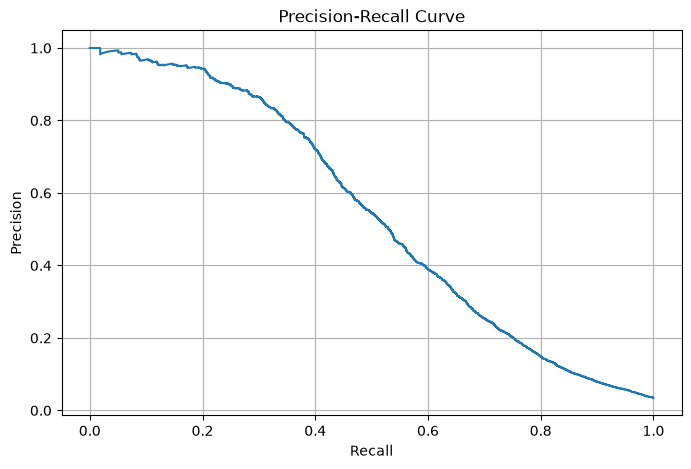

In [15]:
# Cell 14: Precision-Recall curve

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_proba
)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [16]:
# Cell 15: Load test data

print("Loading test data...")

X_test = pd.read_pickle(data_dir / "X_test.pkl")
y_test = pd.read_pickle(data_dir / "y_test.pkl")

# Convert numerical columns to float32
num_cols_test = X_test.select_dtypes(include=["number"]).columns
X_test[num_cols_test] = X_test[num_cols_test].astype(np.float32, copy=False)

print("Test data loaded successfully!")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Loading test data...
Test data loaded successfully!
X_test shape: (88581, 421)
y_test shape: (88581,)


C:\Users\DELL\AppData\Local\Temp\ipykernel_15236\69175790.py:10: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  X_test[num_cols_test] = X_test[num_cols_test].astype(np.float32, copy=False)


In [17]:
# Cell 16: Generate test predictions

print("Generating test predictions...")

y_test_proba = model.predict_proba(X_test)[:, 1]

print("Test predictions generated successfully!")
print("Number of predictions:", len(y_test_proba))
print("Minimum probability:", y_test_proba.min())
print("Maximum probability:", y_test_proba.max())

Generating test predictions...
Test predictions generated successfully!
Number of predictions: 88581
Minimum probability: 0.00019107082884691802
Maximum probability: 0.9986806915108547


In [18]:
# Cell 17: Final test evaluation

from sklearn.metrics import roc_auc_score, average_precision_score

test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_average_precision = average_precision_score(y_test, y_test_proba)

print("Final Test Evaluation")
print("---------------------")
print(f"ROC-AUC Score:       {test_roc_auc:.4f}")
print(f"Average Precision:   {test_average_precision:.4f}")

Final Test Evaluation
---------------------
ROC-AUC Score:       0.8899
Average Precision:   0.5032


In [19]:
# Cell 18: Final classification metrics at threshold 0.20

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

threshold = 0.20

y_test_pred = (y_test_proba >= threshold).astype(int)

print("Test Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

print("\nTest Metrics at Threshold 0.20:")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred):.4f}")

Test Confusion Matrix:
[[83955  1543]
 [ 1644  1439]]

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9808    0.9820    0.9814     85498
           1     0.4826    0.4668    0.4745      3083

    accuracy                         0.9640     88581
   macro avg     0.7317    0.7244    0.7279     88581
weighted avg     0.9635    0.9640    0.9637     88581


Test Metrics at Threshold 0.20:
Precision: 0.4826
Recall:    0.4668
F1-Score:  0.4745
